# 03 Modeling

This notebook builds predictive models for workforce outcomes using the cleaned Stack Overflow 2025 survey data.

The first model predicts job satisfaction using learning pathway flags, experience, salary, education, AI attitudes, and workplace characteristics.

The second model predicts whether a respondent considered or transitioned into a new career or industry.

These models are predictive, not causal. They can show which variables are useful for prediction, but they do not prove that any learning pathway causes higher satisfaction or career change consideration.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [3]:
df = pd.read_csv("../data/processed/stackoverflow_2025_project_cleaned.csv")

df.shape

(49191, 32)

## Model 1: Predicting Job Satisfaction

The first model predicts JobSat, a 0–10 job satisfaction score. This is a regression problem because the target is numeric.

The goal is not to perfectly predict every respondent's job satisfaction, but to test whether learning pathways and workforce characteristics contain useful predictive signal.

In [4]:
learning_features = [
    "learned_online_courses",
    "learned_school",
    "learned_bootcamp",
    "learned_ai",
    "learned_docs",
    "learned_on_job",
    "learned_books",
    "learned_videos"
]

numeric_features = [
    "YearsCode_clean",
    "WorkExp_clean",
    "log_salary"
]

categorical_features = [
    "EdLevel",
    "RemoteWork",
    "OrgSize",
    "AISelect",
    "AIThreat"
]

features = learning_features + numeric_features + categorical_features

target = "JobSat"

In [5]:
model_df = df[features + [target]].copy()

# Drop rows where the outcome is missing.
model_df = model_df.dropna(subset=[target])

model_df.shape

(26670, 17)

In [6]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("binary", binary_transformer, learning_features)
    ]
)

In [8]:
# Linear Regression baseline
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_preds)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))
linear_r2 = r2_score(y_test, linear_preds)

linear_mae, linear_rmse, linear_r2

(1.4685486988518648, np.float64(1.9429177333790872), 0.04914309198912725)

In [9]:
# results table
regression_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [linear_mae],
    "RMSE": [linear_rmse],
    "R2": [linear_r2]
})

regression_results

,Model,MAE,RMSE,R2
0,Linear Regression,1.468549,1.942918,0.049143


In [10]:
# Random Forest Regressor 

rf_regressor = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        n_jobs=-1
    ))
])

rf_regressor.fit(X_train, y_train)

rf_preds = rf_regressor.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

rf_mae, rf_rmse, rf_r2

(1.4735166257157346, np.float64(1.9534218990844925), 0.03883389799934467)

In [11]:
# Updated results table

regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})

regression_results

,Model,MAE,RMSE,R2
0,Linear Regression,1.468549,1.942918,0.049143
1,Random Forest Regressor,1.473517,1.953422,0.038834


## Job Satisfaction Model Interpretation

The linear regression model slightly outperformed the random forest regressor. The linear regression model had an MAE of about 1.47, meaning its predictions were off by roughly 1.47 job satisfaction points on a 0–10 scale on average.

The R² value was about 0.049, meaning the model explained approximately 4.9% of the variation in job satisfaction. This suggests that learning pathways, experience, salary, education, AI attitudes, and selected workplace characteristics contain some predictive signal, but they do not strongly predict job satisfaction by themselves.

This is not necessarily a failed model. Job satisfaction is likely influenced by many factors not fully captured in the survey, such as manager quality, team culture, workload, mission fit, burnout, and promotion opportunities.

## Feature Expansion Check

In [12]:
raw_df = pd.read_csv("../data/raw/results2025.csv", low_memory=False)

raw_df.columns.tolist()

['ResponseId',
 'MainBranch',
 'Age',
 'EdLevel',
 'Employment',
 'EmploymentAddl',
 'WorkExp',
 'LearnCodeChoose',
 'LearnCode',
 'LearnCodeAI',
 'AILearnHow',
 'YearsCode',
 'DevType',
 'OrgSize',
 'ICorPM',
 'RemoteWork',
 'PurchaseInfluence',
 'TechEndorseIntro',
 'TechEndorse_1',
 'TechEndorse_2',
 'TechEndorse_3',
 'TechEndorse_4',
 'TechEndorse_5',
 'TechEndorse_6',
 'TechEndorse_7',
 'TechEndorse_8',
 'TechEndorse_9',
 'TechEndorse_13',
 'TechEndorse_13_TEXT',
 'TechOppose_1',
 'TechOppose_2',
 'TechOppose_3',
 'TechOppose_5',
 'TechOppose_7',
 'TechOppose_9',
 'TechOppose_11',
 'TechOppose_13',
 'TechOppose_16',
 'TechOppose_15',
 'TechOppose_15_TEXT',
 'Industry',
 'JobSatPoints_1',
 'JobSatPoints_2',
 'JobSatPoints_3',
 'JobSatPoints_4',
 'JobSatPoints_5',
 'JobSatPoints_6',
 'JobSatPoints_7',
 'JobSatPoints_8',
 'JobSatPoints_9',
 'JobSatPoints_10',
 'JobSatPoints_11',
 'JobSatPoints_13',
 'JobSatPoints_14',
 'JobSatPoints_15',
 'JobSatPoints_16',
 'JobSatPoints_15_TEXT',
 

In [13]:
keywords = [
    "Job",
    "Work",
    "Remote",
    "Org",
    "AI",
    "Learn",
    "Dev",
    "Industry",
    "Tools",
    "Frustration",
    "Professional",
    "Comp",
    "Years"
]

for keyword in keywords:
    matches = [col for col in raw_df.columns if keyword.lower() in col.lower()]
    print(f"\n{keyword}:")
    print(matches)


Job:
['JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'JobSatPoints_15_TEXT', 'JobSat']

Work:
['WorkExp', 'RemoteWork', 'ToolCountWork', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'DevEnvsHaveWorkedWith', 'DevEnvsWantToWorkWith', 'SOTagsHaveWorkedWith', 'SOTagsWantToWorkWith', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'CommPlatformHaveWorkedWith', 'CommPlatformWantToWorkWith', 'AIModelsHaveWorkedWith', 'AIModelsWantToWorkWith']

Remote:
['RemoteWork']

Org:
['OrgSize']

AI:
['MainBranch', 'LearnCodeAI', 'AILearnHow', 'AIThreat', 'AIModelsChoice', 'AIModelsHaveWorkedWith', 

In [14]:
# Quick Numeric Correlation Check

numeric_check_cols = [
    "JobSat",
    "YearsCode_clean",
    "WorkExp_clean",
    "ConvertedCompYearly",
    "log_salary",
    "career_change_considered"
]

df[numeric_check_cols].corr(numeric_only=True)["JobSat"].sort_values(ascending=False)

JobSat                      1.000000
WorkExp_clean               0.105288
YearsCode_clean             0.093895
log_salary                  0.067154
ConvertedCompYearly         0.023568
career_change_considered   -0.272650
Name: JobSat, dtype: float64

In [15]:
# Categorical variables by average JobSat

categorical_check_cols = [
    "RemoteWork",
    "OrgSize",
    "EdLevel",
    "AISelect",
    "AIThreat",
    "DevType",
   
]

for col in categorical_check_cols:
    print("\n", col)
    display(
        df.groupby(col)["JobSat"]
        .agg(["count", "mean", "median"])
        .query("count >= 100")
        .sort_values("mean", ascending=False)
        .head(8)
    )


 RemoteWork


,count,mean,median
RemoteWork,,,
"Your choice (very flexible, you can come in when you want or just as needed)",2848,7.426966,8.0
Remote,7908,7.323849,8.0
"Hybrid (some in-person, leans heavy to flexibility)",4046,7.207365,8.0
Missing,3873,7.113865,8.0
"Hybrid (some remote, leans heavy to in-person)",4499,7.082240,7.0
In-person,3496,6.988272,7.0



 OrgSize


,count,mean,median
OrgSize,,,
"Just me - I am a freelancer, sole proprietor, etc.",865,7.565318,8.0
Less than 20 employees,3901,7.346065,8.0
20 to 99 employees,4816,7.224460,7.0
100 to 499 employees,4266,7.210502,8.0
"5,000 to 9,999 employees",1015,7.193103,7.0
500 to 999 employees,1655,7.166767,7.0
"1,000 to 4,999 employees",2734,7.136430,7.0
I don’t know,444,7.132883,7.0



 EdLevel


...

,count,mean,median
AISelect,,,
"Yes, I use AI tools daily",12599,7.289547,8.0
"Yes, I use AI tools weekly",4353,7.142890,7.0
"No, and I don't plan to",3643,7.138073,8.0
"No, but I plan to soon",1135,7.110132,8.0
"Yes, I use AI tools monthly or infrequently",3188,7.109473,7.0
Missing,1752,7.079338,7.0



 AIThreat


,count,mean,median
AIThreat,,,
Missing,134,7.708955,8.0
No,17076,7.404427,8.0
I'm not sure,5583,6.992298,7.0
Yes,3877,6.594532,7.0



 DevType


,count,mean,median
DevType,,,
"Founder, technology or otherwise",235,8.382979,9.0
"Senior executive (C-suite, VP, etc.)",273,8.150183,8.0
Cybersecurity or InfoSec professional,113,7.601770,8.0
Applied scientist,109,7.550459,8.0
"Architect, software or solutions",1865,7.542091,8.0
"Developer, game or graphics",301,7.368771,8.0
Engineering manager,595,7.368067,8.0
Academic researcher,285,7.361404,8.0


In [16]:
categorical_features_expanded = [
    "EdLevel",
    "RemoteWork",
    "OrgSize",
    "AISelect",
    "AIThreat",
    "DevType"
]

features_expanded = learning_features + numeric_features + categorical_features_expanded

model_df_expanded = df[features_expanded + ["JobSat"]].copy()
model_df_expanded = model_df_expanded.dropna(subset=["JobSat"])

X_expanded = model_df_expanded[features_expanded]
y_expanded = model_df_expanded["JobSat"]

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_expanded,
    y_expanded,
    test_size=0.2,
    random_state=42
)

preprocessor_expanded = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features_expanded),
        ("binary", binary_transformer, learning_features)
    ]
)

expanded_linear = Pipeline(steps=[
    ("preprocessor", preprocessor_expanded),
    ("model", LinearRegression())
])

expanded_linear.fit(X_train_exp, y_train_exp)

expanded_preds = expanded_linear.predict(X_test_exp)

expanded_mae = mean_absolute_error(y_test_exp, expanded_preds)
expanded_rmse = np.sqrt(mean_squared_error(y_test_exp, expanded_preds))
expanded_r2 = r2_score(y_test_exp, expanded_preds)

expanded_mae, expanded_rmse, expanded_r2

(1.4640760947759923, np.float64(1.9357522366561812), 0.05614369533281327)

In [17]:
regression_results_expanded = pd.DataFrame({
    "Model": ["Original Linear Regression", "Expanded Linear Regression"],
    "MAE": [linear_mae, expanded_mae],
    "RMSE": [linear_rmse, expanded_rmse],
    "R2": [linear_r2, expanded_r2]
})

regression_results_expanded

,Model,MAE,RMSE,R2
0,Original Linear Regression,1.468549,1.942918,0.049143
1,Expanded Linear Regression,1.464076,1.935752,0.056144


## Expanded Regression Model Interpretation

Adding DevType to the regression model slightly improved performance. The expanded linear regression model had a lower MAE and RMSE than the original model, and R² increased from approximately 0.049 to 0.056.

This means the expanded model explained about 5.6% of the variation in job satisfaction, compared with about 4.9% in the original model. The improvement suggests that developer role type adds some predictive information, but the overall explanatory power remains limited.

This supports the conclusion that job satisfaction is difficult to predict from learning pathways and broad workforce characteristics alone. The available variables contain some signal, but much of job satisfaction likely depends on factors not captured in this survey, such as team culture, manager quality, workload, burnout, mission fit, and promotion opportunity.

# Part 2: Predicting Career Change Consideration

This section builds classification models to predict whether a respondent considered or transitioned into a new career or industry in the past year.

The target variable is `career_change_considered`.

This is a classification problem because the outcome is binary:

- 0 = did not consider or transition
- 1 = considered or transitioned

As with the regression model, this is predictive rather than causal. The model can identify patterns associated with career change consideration, but it does not prove that any specific feature causes someone to consider changing careers.

In [18]:
# Check target column balance in data
df["career_change_considered"].value_counts(dropna=False)

career_change_considered
1.0    19322
0.0    16205
NaN    13664
Name: count, dtype: int64

In [19]:
df["career_change_considered"].value_counts(normalize=True, dropna=True) * 100

career_change_considered
1.0    54.386804
0.0    45.613196
Name: proportion, dtype: float64

The target variable is fairly balanced among respondents who answered the question, which makes it reasonable to use accuracy along with precision, recall, F1, and ROC-AUC.

In [20]:
# Set up classification data using same features as regression model
classification_target = "career_change_considered"

classification_df = df[features + [classification_target]].copy()

# Drop rows where the outcome is missing.
classification_df = classification_df.dropna(subset=[classification_target])

classification_df.shape

(35527, 17)

In [21]:

X = classification_df[features]
y = classification_df[classification_target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# I used stratify=y because this is a classification problem. 
# It preserves the proportion of each target class in the training and testing sets,
#  making both sets more representative of the full dataset.

In [22]:
# Logistic Regression Baseline
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

In [23]:
log_accuracy = accuracy_score(y_test, log_preds)
log_precision = precision_score(y_test, log_preds)
log_recall = recall_score(y_test, log_preds)
log_f1 = f1_score(y_test, log_preds)
log_auc = roc_auc_score(y_test, log_probs)

log_accuracy, log_precision, log_recall, log_f1, log_auc

(0.5835913312693498,
 0.601889338731444,
 0.6923673997412678,
 0.643965828420166,
 0.6042238572494314)

In [67]:
# Random Forest Classifier
rf_classifier = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        max_depth=10,
        n_jobs=-1
    ))
])

rf_classifier.fit(X_train, y_train)

rf_preds = rf_classifier.predict(X_test)
rf_probs = rf_classifier.predict_proba(X_test)[:, 1]

In [68]:
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probs)

rf_accuracy, rf_precision, rf_recall, rf_f1, rf_auc

(0.5933014354066986,
 0.5976366913679151,
 0.7720569210866753,
 0.6737412508466922,
 0.613716958455558)

In [26]:
# Results table
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest Classifier"],
    "Accuracy": [log_accuracy, rf_accuracy],
    "Precision": [log_precision, rf_precision],
    "Recall": [log_recall, rf_recall],
    "F1": [log_f1, rf_f1],
    "ROC_AUC": [log_auc, rf_auc]
})

classification_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.583591,0.601889,0.692367,0.643966,0.604224
1,Random Forest Classifier,0.591753,0.597610,0.763519,0.670453,0.611527


In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'model__class_weight': None, 'model__max_depth': 15, 'model__min_samples_leaf': 10, 'model__n_estimators': 300}
0.6167965280547277


In [28]:
# Confusion Matrix

# Starting with Regression

confusion_matrix(y_test, log_preds)

log_cm = confusion_matrix(y_test, log_preds)

log_cm_df = pd.DataFrame(
    log_cm,
    index=["Actual 0: No change considered", "Actual 1: Considered/transitioned"],
    columns=["Predicted 0", "Predicted 1"]
)

log_cm_df

,Predicted 0,Predicted 1
Actual 0: No change considered,1471,1770
Actual 1: Considered/transitioned,1189,2676


In [29]:
# Confusion Matrix for Random Forest

rf_cm = confusion_matrix(y_test, rf_preds)

rf_cm_df = pd.DataFrame(
    rf_cm,
    index=["Actual 0: No change considered", "Actual 1: Considered/transitioned"],
    columns=["Predicted 0", "Predicted 1"]
)

rf_cm_df

,Predicted 0,Predicted 1
Actual 0: No change considered,1254,1987
Actual 1: Considered/transitioned,914,2951


## Career Change Classification Model Interpretation

The random forest classifier performed slightly better than the logistic regression model overall. It had a higher accuracy, recall, F1 score, and ROC-AUC.

The strongest improvement was recall. The random forest correctly identified about 76% of respondents who considered or transitioned into a new career or industry, compared with about 69% for logistic regression. This suggests the random forest was better at finding the positive class.

However, the random forest also had slightly lower precision, meaning it produced more false positives. In plain language, it was more aggressive about predicting career change consideration.

The ROC-AUC values for both models were around 0.60 to 0.61. This means the models performed better than random guessing, but they were not strong classifiers. These results suggest that learning pathways, experience, salary, education, AI attitudes, and workplace characteristics contain some predictive signal, but they are not enough to confidently predict career change consideration at the individual level.

For workforce-development purposes, this model is more useful for identifying broad patterns than for labeling individuals as likely to change careers.

## Confusion Matrix Interpretation

The logistic regression model correctly identified 2,676 respondents who considered or transitioned into a new career or industry, while missing 1,189. It also incorrectly classified 1,770 respondents as having considered or transitioned when they had not.

The random forest classifier identified more of the actual career-change-consideration cases, correctly classifying 2,951 respondents in that group and missing only 914. However, it also produced more false positives, incorrectly classifying 1,987 respondents as having considered or transitioned when they had not.

Overall, the random forest had stronger recall for the career-change-consideration group, while the logistic regression model was somewhat less aggressive. In a workforce-development setting, higher recall may be useful if the goal is to identify broad patterns associated with career mobility. However, the false positives show why this model should not be interpreted as a definitive individual-level risk prediction.

# New Model Stage

## Turn classifier into bands instead of yes/no  
High, medium, and low probability


In [30]:
test_band_df = X_test.copy()
test_band_df["actual"] = y_test.values

test_band_df["predicted_probability"] = rf_classifier.predict_proba(X_test)[:, 1]

test_band_df["probability_band"] = pd.cut(
    test_band_df["predicted_probability"],
    bins=[0, 0.4, 0.6, 1.0],
    labels=["Lower", "Middle", "Higher"]
)

test_band_df["probability_band"].value_counts()

test_band_summary = (
    test_band_df
    .groupby("probability_band")["actual"]
    .agg(["count", "mean"])
)

test_band_summary["actual_percent_considered"] = (
    test_band_summary["mean"] * 100
).round(1)

test_band_summary



C:\Users\patri\AppData\Local\Temp\ipykernel_41824\1275567123.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("probability_band")["actual"]


,count,mean,actual_percent_considered
probability_band,,,
Lower,354,0.305085,30.5
Middle,5176,0.524923,52.5
Higher,1576,0.659898,66.0


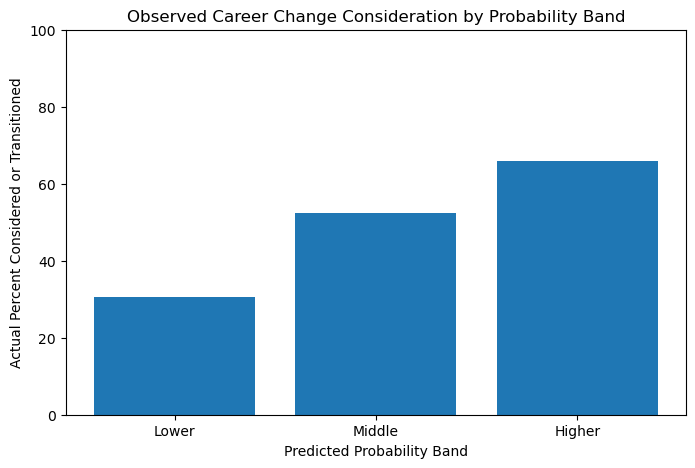

In [31]:
plt.figure(figsize=(8, 5))
plt.bar(
    test_band_summary.index.astype(str),
    test_band_summary["actual_percent_considered"]
)

plt.xlabel("Predicted Probability Band")
plt.ylabel("Actual Percent Considered or Transitioned")
plt.title("Observed Career Change Consideration by Probability Band")
plt.ylim(0, 100)
plt.show()

In [32]:
# This version had data leakage
# classification_df["predicted_probability"] = rf_classifier.predict_proba(
#     classification_df[features]
# )[:, 1]

# classification_df["probability_band"] = pd.cut(
#     classification_df["predicted_probability"],
#     bins=[0, 0.4, 0.6, 1.0],
#     labels=["Lower", "Middle", "Higher"]
# )

# classification_df["probability_band"].value_counts()

In [33]:
# band_summary = (
#     classification_df
#     .groupby("probability_band")["career_change_considered"]
#     .agg(["count", "mean"])
# )

# band_summary["actual_percent_considered"] = (
#     band_summary["mean"] * 100
# ).round(1)

# band_summary

In [34]:
# band_summary = (
#     classification_df
#     .groupby("probability_band")["career_change_considered"]
#     .agg(["count", "mean"])
# )

# band_summary["actual_percent_considered"] = (
#     band_summary["mean"] * 100
# ).round(1)

# band_summary

In [35]:
# plt.figure(figsize=(8, 5))
# plt.bar(
#     band_summary.index.astype(str),
#     band_summary["actual_percent_considered"]
# )

# plt.xlabel("Predicted Probability Band")
# plt.ylabel("Actual Percent Considered or Transitioned")
# plt.title("Observed Career Change Consideration by Predicted Probability Band")
# plt.ylim(0, 100)
# plt.show()

## Probability Band Interpretation

The probability bands were evaluated on the held-out test set, meaning the model was tested on data that was not used during training.

The probability bands show a useful group-level pattern. Respondents in the lower-probability band had an observed career change consideration rate of 30.5%. Respondents in the middle band had an observed rate of 52.5%. Respondents in the higher-probability band had an observed rate of 66.0%.

This means the model is not just guessing randomly. It is sorting respondents into groups with different observed rates of career change consideration. The separation is not strong enough to support confident individual-level prediction, but it is useful for workforce pattern recognition.

For workforce-development purposes, the model is best understood as a tool for identifying broad patterns associated with career change consideration, not as a tool for labeling individual people.

# Modeling Summary
Regression:
Job satisfaction is hard to predict from these variables.

Classification:
Career change consideration is only moderately predictable as yes/no,
but probability bands show clear separation across lower, middle, and higher likelihood groups.

## Random Forest Feature Importance

In [36]:
# Get feature names after preprocessing
feature_names = rf_classifier.named_steps["preprocessor"].get_feature_names_out()

# Get feature importances from the random forest model
importances = rf_classifier.named_steps["model"].feature_importances_

# Put them into a dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
2,num__log_salary,0.115594
0,num__YearsCode_clean,0.110497
1,num__WorkExp_clean,0.104592
36,cat__AIThreat_No,0.079733
37,cat__AIThreat_Yes,0.074007
38,binary__learned_online_courses,0.041894
10,cat__EdLevel_Secondary school (e.g. American h...,0.024430
41,binary__learned_ai,0.023734
42,binary__learned_docs,0.022246
34,cat__AIThreat_I'm not sure,0.020527


In [37]:
feature_importance["clean_feature"] = (
    feature_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("binary__", "", regex=False)
)

feature_importance.head(20)

,feature,importance,clean_feature
2,num__log_salary,0.115594,log_salary
0,num__YearsCode_clean,0.110497,YearsCode_clean
1,num__WorkExp_clean,0.104592,WorkExp_clean
36,cat__AIThreat_No,0.079733,AIThreat_No
37,cat__AIThreat_Yes,0.074007,AIThreat_Yes
38,binary__learned_online_courses,0.041894,learned_online_courses
10,cat__EdLevel_Secondary school (e.g. American h...,0.024430,EdLevel_Secondary school (e.g. American high s...
41,binary__learned_ai,0.023734,learned_ai
42,binary__learned_docs,0.022246,learned_docs
34,cat__AIThreat_I'm not sure,0.020527,AIThreat_I'm not sure


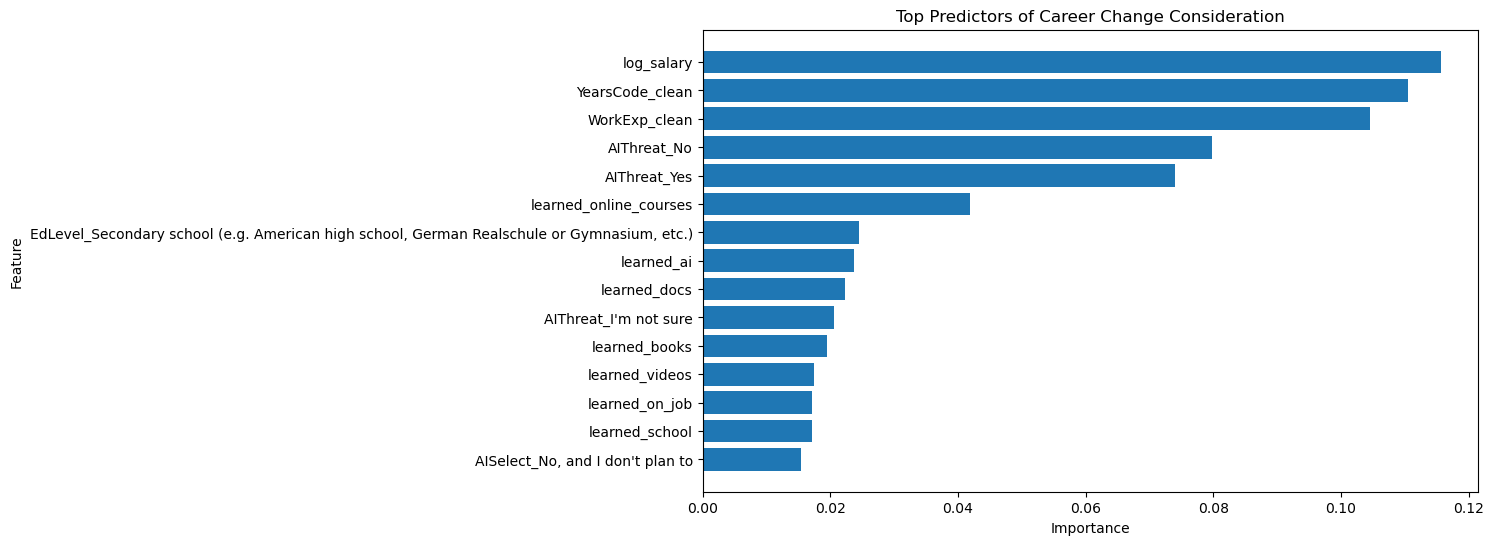

In [38]:
top_features = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["clean_feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Predictors of Career Change Consideration")
plt.show()

In [39]:
def assign_feature_group(feature):
    if "learned_" in feature:
        return "Learning pathways"
    elif "YearsCode" in feature or "WorkExp" in feature or "salary" in feature:
        return "Experience and compensation"
    elif "AISelect" in feature or "AIThreat" in feature:
        return "AI use and attitudes"
    elif "RemoteWork" in feature or "OrgSize" in feature:
        return "Work setting"
    elif "EdLevel" in feature:
        return "Education"
    else:
        return "Other"

feature_importance["feature_group"] = feature_importance["clean_feature"].apply(assign_feature_group)

group_importance = (
    feature_importance
    .groupby("feature_group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

group_importance

feature_group
Experience and compensation    0.330683
AI use and attitudes           0.245780
Learning pathways              0.173510
Work setting                   0.162093
Education                      0.087933
Name: importance, dtype: float64

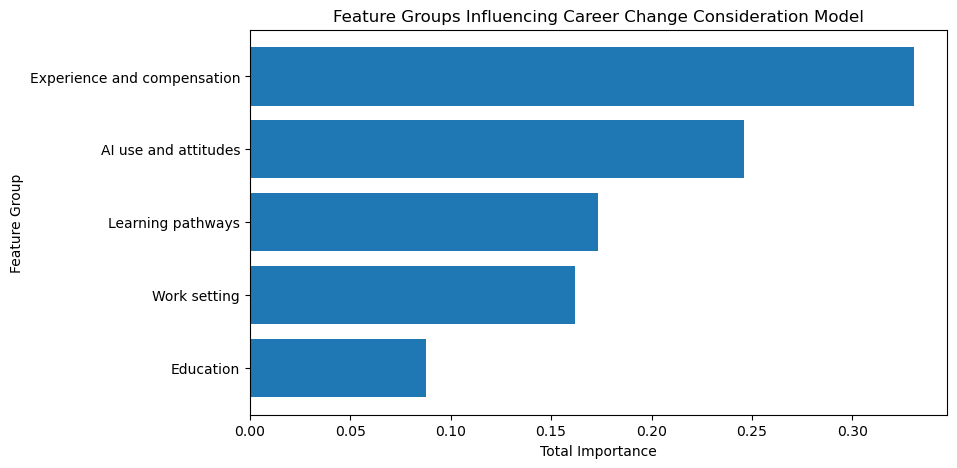

In [40]:
group_importance_plot = group_importance.sort_values()

plt.figure(figsize=(9, 5))
plt.barh(group_importance_plot.index, group_importance_plot.values)
plt.xlabel("Total Importance")
plt.ylabel("Feature Group")
plt.title("Feature Groups Influencing Career Change Consideration Model")
plt.show()

## Feature Importance

After evaluating the career change consideration model, I examined which inputs contributed most to the random forest classifier. Feature importance does not prove causation, but it helps identify which learning, workforce, and workplace characteristics the model relied on most when assigning respondents to lower, middle, or higher predicted career mobility bands.

## Career Change Model Without Salary

The first random forest model included log-transformed salary, and salary appeared as one of the strongest predictors. Because compensation can dominate workforce behavior and may not be directly controlled by training-program leaders, I also evaluated a second model without salary.

This model tests whether learning pathways, experience, education, work setting, organization size, and AI attitudes still provide useful signal for career change consideration when salary is removed.

In [41]:
# Create feature set without salary
numeric_features_no_salary = ["YearsCode_clean", "WorkExp_clean"]

features_no_salary = (
    learning_features 
    + numeric_features_no_salary 
    + categorical_features
)

classification_target = "career_change_considered"

classification_df_no_salary = df[features_no_salary + [classification_target]].copy()
classification_df_no_salary = classification_df_no_salary.dropna(subset=[classification_target])

X_no_salary = classification_df_no_salary[features_no_salary]
y_no_salary = classification_df_no_salary[classification_target].astype(int)

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_salary,
    y_no_salary,
    test_size=0.2,
    random_state=42,
    stratify=y_no_salary
)

In [42]:
numeric_transformer_no_salary = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_no_salary = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_no_salary, numeric_features_no_salary),
        ("cat", categorical_transformer, categorical_features),
        ("binary", binary_transformer, learning_features)
    ]
)

In [43]:
# Train and evaluate

rf_classifier_no_salary = Pipeline(steps=[
    ("preprocessor", preprocessor_no_salary),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        n_jobs=-1
    ))
])

rf_classifier_no_salary.fit(X_train_ns, y_train_ns)

rf_ns_preds = rf_classifier_no_salary.predict(X_test_ns)
rf_ns_probs = rf_classifier_no_salary.predict_proba(X_test_ns)[:, 1]

rf_no_salary_results = {
    "Accuracy": accuracy_score(y_test_ns, rf_ns_preds),
    "Precision": precision_score(y_test_ns, rf_ns_preds),
    "Recall": recall_score(y_test_ns, rf_ns_preds),
    "F1": f1_score(y_test_ns, rf_ns_preds),
    "ROC_AUC": roc_auc_score(y_test_ns, rf_ns_probs)
}

rf_no_salary_results

{'Accuracy': 0.5862651280607937,
 'Precision': 0.5931520644511581,
 'Recall': 0.7619663648124192,
 'F1': 0.6670441676104191,
 'ROC_AUC': 0.6071718158315216}

In [44]:
# getting original results

rf_results = {
    "Accuracy": accuracy_score(y_test, rf_preds),
    "Precision": precision_score(y_test, rf_preds),
    "Recall": recall_score(y_test, rf_preds),
    "F1": f1_score(y_test, rf_preds),
    "ROC_AUC": roc_auc_score(y_test, rf_probs)
}

rf_results

{'Accuracy': 0.5917534477905995,
 'Precision': 0.5976103685702714,
 'Recall': 0.7635187580853816,
 'F1': 0.6704532545723049,
 'ROC_AUC': 0.6115266358066701}

In [45]:
comparison_results = pd.DataFrame({
    "Random Forest With Salary": rf_results,
    "Random Forest Without Salary": rf_no_salary_results
})

comparison_results

,Random Forest With Salary,Random Forest Without Salary
Accuracy,0.591753,0.586265
Precision,0.597610,0.593152
Recall,0.763519,0.761966
F1,0.670453,0.667044
ROC_AUC,0.611527,0.607172


Now I am checking what is influencing the no salary model

In [46]:
# Feature importance for the no-salary random forest model
feature_names_ns = rf_classifier_no_salary.named_steps["preprocessor"].get_feature_names_out()
importances_ns = rf_classifier_no_salary.named_steps["model"].feature_importances_

feature_importance_ns = pd.DataFrame({
    "feature": feature_names_ns,
    "importance": importances_ns
}).sort_values("importance", ascending=False)

feature_importance_ns["clean_feature"] = (
    feature_importance_ns["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("binary__", "", regex=False)
)

feature_importance_ns.head(20)

,feature,importance,clean_feature
0,num__YearsCode_clean,0.130583,YearsCode_clean
1,num__WorkExp_clean,0.124365,WorkExp_clean
35,cat__AIThreat_No,0.083651,AIThreat_No
36,cat__AIThreat_Yes,0.079086,AIThreat_Yes
37,binary__learned_online_courses,0.046715,learned_online_courses
40,binary__learned_ai,0.027263,learned_ai
9,cat__EdLevel_Secondary school (e.g. American h...,0.026732,EdLevel_Secondary school (e.g. American high s...
33,cat__AIThreat_I'm not sure,0.023170,AIThreat_I'm not sure
41,binary__learned_docs,0.022877,learned_docs
43,binary__learned_books,0.022370,learned_books


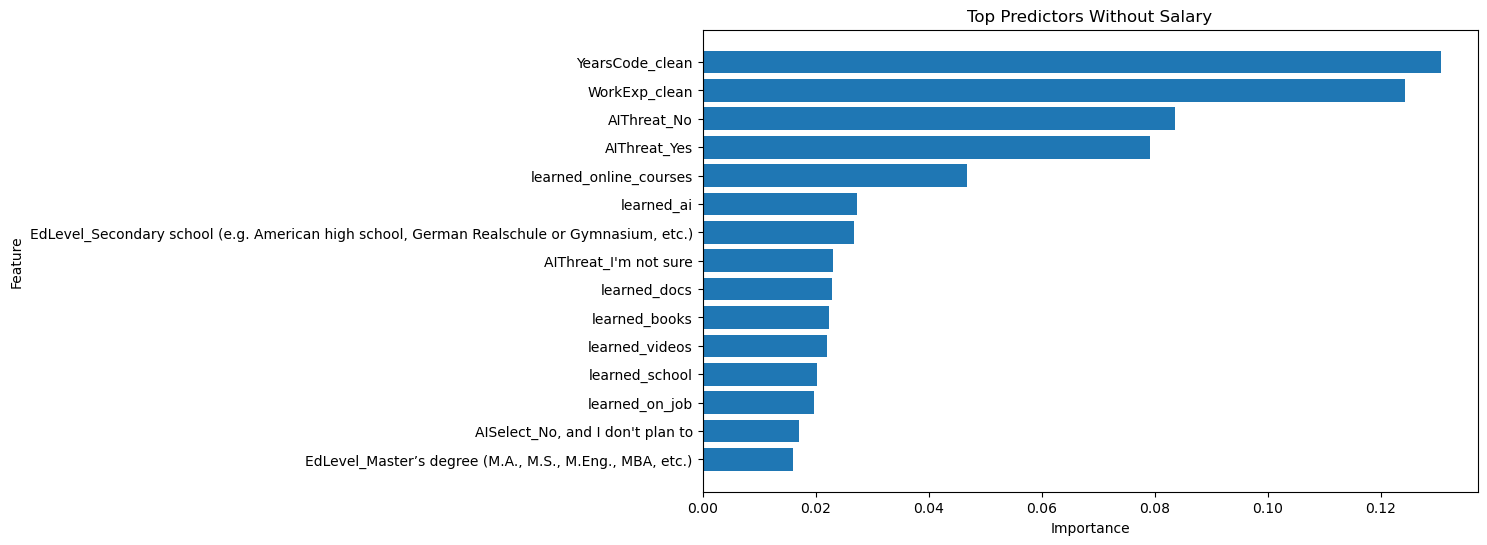

In [47]:
top_features_ns = feature_importance_ns.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features_ns["clean_feature"], top_features_ns["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Predictors Without Salary")
plt.show()

In [48]:
def assign_feature_group(feature):
    if "learned_" in feature:
        return "Learning pathways"
    elif "YearsCode" in feature or "WorkExp" in feature:
        return "Experience"
    elif "AISelect" in feature or "AIThreat" in feature:
        return "AI use and attitudes"
    elif "RemoteWork" in feature or "OrgSize" in feature:
        return "Work setting"
    elif "EdLevel" in feature:
        return "Education"
    else:
        return "Other"

feature_importance_ns["feature_group"] = feature_importance_ns["clean_feature"].apply(assign_feature_group)

group_importance_ns = (
    feature_importance_ns
    .groupby("feature_group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

group_importance_ns

feature_group
AI use and attitudes    0.268990
Experience              0.254948
Learning pathways       0.196958
Work setting            0.179900
Education               0.099204
Name: importance, dtype: float64

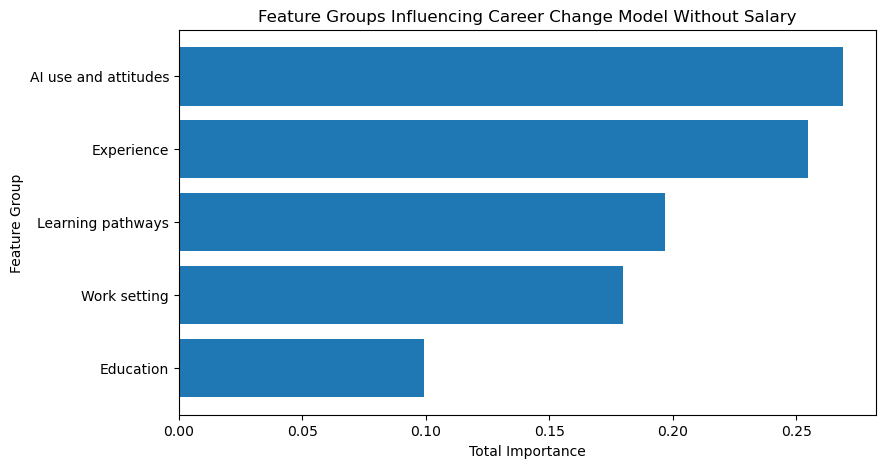

In [49]:
group_importance_ns_plot = group_importance_ns.sort_values()

plt.figure(figsize=(9, 5))
plt.barh(group_importance_ns_plot.index, group_importance_ns_plot.values)
plt.xlabel("Total Importance")
plt.ylabel("Feature Group")
plt.title("Feature Groups Influencing Career Change Model Without Salary")
plt.show()

Salary was the top individual feature in the original model, but removing it barely changed performance. This suggests salary carried useful signal, but the model was not dependent on salary alone. When salary was removed, the model shifted to other related signals such as experience, AI attitudes, learning pathways, education, and work setting.

## Development-Focused Model

To test whether the model relied mainly on compensation and career-stage variables, I evaluated a third model that removed salary, years coding, and work experience. This development-focused model uses learning pathways, education, work setting, organization size, and AI attitudes to test whether workforce-development variables still provide signal for career change consideration.

In [50]:
# Development-focused feature set: no salary, no years coding, no work experience
numeric_features_dev = []

features_dev = learning_features + categorical_features

classification_df_dev = df[features_dev + [classification_target]].copy()
classification_df_dev = classification_df_dev.dropna(subset=[classification_target])

X_dev = classification_df_dev[features_dev]
y_dev = classification_df_dev[classification_target].astype(int)

X_train_dev, X_test_dev, y_train_dev, y_test_dev = train_test_split(
    X_dev,
    y_dev,
    test_size=0.2,
    random_state=42,
    stratify=y_dev
)

In [51]:
preprocessor_dev = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("binary", binary_transformer, learning_features)
    ]
)

In [52]:
rf_classifier_dev = Pipeline(steps=[
    ("preprocessor", preprocessor_dev),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        n_jobs=-1
    ))
])

rf_classifier_dev.fit(X_train_dev, y_train_dev)

rf_dev_preds = rf_classifier_dev.predict(X_test_dev)
rf_dev_probs = rf_classifier_dev.predict_proba(X_test_dev)[:, 1]

rf_dev_results = {
    "Accuracy": accuracy_score(y_test_dev, rf_dev_preds),
    "Precision": precision_score(y_test_dev, rf_dev_preds),
    "Recall": recall_score(y_test_dev, rf_dev_preds),
    "F1": f1_score(y_test_dev, rf_dev_preds),
    "ROC_AUC": roc_auc_score(y_test_dev, rf_dev_probs)
}

rf_dev_results

{'Accuracy': 0.5745848578665916,
 'Precision': 0.5887811050189793,
 'Recall': 0.7223803363518758,
 'F1': 0.6487742535145812,
 'ROC_AUC': 0.5899916696370444}

In [53]:
comparison_results = pd.DataFrame({
    "Full Model": rf_results,
    "No Salary": rf_no_salary_results,
    "Development-Focused": rf_dev_results
})

comparison_results

,Full Model,No Salary,Development-Focused
Accuracy,0.591753,0.586265,0.574585
Precision,0.597610,0.593152,0.588781
Recall,0.763519,0.761966,0.722380
F1,0.670453,0.667044,0.648774
ROC_AUC,0.611527,0.607172,0.589992


## Model Sensitivity Interpretation

I compared three versions of the career change consideration model. The full model included salary, experience, learning pathways, education, AI attitudes, and work setting. The no-salary model removed compensation, and the development-focused model removed salary, years coding, and work experience.

Removing salary alone had very little effect on performance. ROC-AUC decreased from 0.612 to 0.607, suggesting the model was not dependent on compensation alone. Removing both compensation and experience reduced performance more noticeably, with ROC-AUC decreasing to 0.590. However, the development-focused model still performed above random guessing, which suggests that learning pathways, education, AI attitudes, and work setting still contain some signal related to career change consideration.

Overall, career change consideration appears to be influenced by a combination of career stage, compensation, AI attitudes, workplace context, and learning pathways rather than any single factor.

## Development-Focused Model Without AI Threat

Because AI threat perception may be closely related to career change consideration, I evaluated one additional model that removes `AIThreat`. This model tests whether learning pathways, education, work setting, organization size, and AI usage still provide signal without salary, experience, or direct AI-related career anxiety.

In [54]:
# Development-focused model without salary, experience, or AI threat
categorical_features_dev_no_threat = [
    "EdLevel",
    "RemoteWork",
    "OrgSize",
    "AISelect"
]

features_dev_no_threat = learning_features + categorical_features_dev_no_threat

classification_df_dev_no_threat = df[
    features_dev_no_threat + [classification_target]
].copy()

classification_df_dev_no_threat = classification_df_dev_no_threat.dropna(
    subset=[classification_target]
)

X_dev_no_threat = classification_df_dev_no_threat[features_dev_no_threat]
y_dev_no_threat = classification_df_dev_no_threat[classification_target].astype(int)

X_train_dnt, X_test_dnt, y_train_dnt, y_test_dnt = train_test_split(
    X_dev_no_threat,
    y_dev_no_threat,
    test_size=0.2,
    random_state=42,
    stratify=y_dev_no_threat
)

In [55]:
preprocessor_dev_no_threat = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features_dev_no_threat),
        ("binary", binary_transformer, learning_features)
    ]
)

In [56]:
rf_classifier_dev_no_threat = Pipeline(steps=[
    ("preprocessor", preprocessor_dev_no_threat),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        n_jobs=-1
    ))
])

rf_classifier_dev_no_threat.fit(X_train_dnt, y_train_dnt)

rf_dnt_preds = rf_classifier_dev_no_threat.predict(X_test_dnt)
rf_dnt_probs = rf_classifier_dev_no_threat.predict_proba(X_test_dnt)[:, 1]

rf_dev_no_threat_results = {
    "Accuracy": accuracy_score(y_test_dnt, rf_dnt_preds),
    "Precision": precision_score(y_test_dnt, rf_dnt_preds),
    "Recall": recall_score(y_test_dnt, rf_dnt_preds),
    "F1": f1_score(y_test_dnt, rf_dnt_preds),
    "ROC_AUC": roc_auc_score(y_test_dnt, rf_dnt_probs)
}

rf_dev_no_threat_results

{'Accuracy': 0.5579791725302561,
 'Precision': 0.5646890636168692,
 'Recall': 0.8175937904269082,
 'F1': 0.668005496247754,
 'ROC_AUC': 0.5640084413280203}

In [57]:
comparison_results = pd.DataFrame({
    "Full Model": rf_results,
    "No Salary": rf_no_salary_results,
    "Development-Focused": rf_dev_results,
    "No Salary/Experience/AIThreat": rf_dev_no_threat_results
})

comparison_results

,Full Model,No Salary,Development-Focused,No Salary/Experience/AIThreat
Accuracy,0.591753,0.586265,0.574585,0.557979
Precision,0.597610,0.593152,0.588781,0.564689
Recall,0.763519,0.761966,0.722380,0.817594
F1,0.670453,0.667044,0.648774,0.668005
ROC_AUC,0.611527,0.607172,0.589992,0.564008


## Sensitivity Check Interpretation

I compared four versions of the career change consideration model to test whether the model depended on compensation, experience, or AI-related career concern.

Removing salary alone had very little effect on performance, with ROC-AUC decreasing from 0.612 to 0.607. Removing salary, years coding, and work experience reduced performance more noticeably, with ROC-AUC decreasing to 0.590. Removing AI threat perception as well reduced ROC-AUC further to 0.564.

This suggests that salary alone did not drive the model. However, career stage and AI-related career concern carried important signal. Learning pathways, education, AI usage, work setting, and organization size still provided some signal, but they were weaker predictors when compensation, experience, and AI threat perception were removed.

## Classification Model Evaluation Metrics

The table compares four versions of the random forest classification model used to predict career change consideration. The target variable is whether a respondent had considered or transitioned into a new career or industry.

### Model Versions

**Full Model**  
Includes salary, years coding, work experience, learning pathways, education level, work setting, organization size, AI usage, and AI threat perception.

**No Salary**  
Removes salary but keeps experience, learning pathways, education, work setting, organization size, AI usage, and AI threat perception.

**Development-Focused**  
Removes salary, years coding, and work experience. This model focuses more directly on learning pathways, education, work setting, organization size, and AI attitudes.

**No Salary/Experience/AIThreat**  
Removes salary, years coding, work experience, and AI threat perception. This tests whether learning pathways, education, work setting, organization size, and AI usage still provide signal without compensation, career-stage, or AI-threat variables.

### Metric Definitions

**Accuracy**  
Accuracy shows the overall percentage of correct predictions. For example, an accuracy of 0.59 means the model correctly classified about 59% of respondents in the test set.

**Precision**  
Precision answers: when the model predicted that a respondent had considered or transitioned careers, how often was it correct? Higher precision means fewer false positives.

**Recall**  
Recall answers: out of all respondents who actually had considered or transitioned careers, how many did the model successfully identify? Higher recall means the model missed fewer respondents in the career-change-considered group.

**F1 Score**  
F1 combines precision and recall into one balanced score. It is useful when both false positives and false negatives matter.

**ROC-AUC**  
ROC-AUC measures how well the model separates the two groups across different classification thresholds. A score of 0.50 would be close to random guessing, while 1.00 would be perfect separation. In this project, ROC-AUC values between 0.56 and 0.61 suggest the model has weak-to-moderate group-level signal, but not enough for strong individual-level prediction.

### Interpretation

The full model performed best, with a ROC-AUC of 0.612 and an F1 score of 0.670. Removing salary alone had very little effect, suggesting the model was not dependent on compensation by itself. Removing salary, years coding, and work experience reduced performance more noticeably, which suggests career stage and experience carried important signal.

The final model, which also removed AI threat perception, had the lowest ROC-AUC at 0.564. This suggests that AI-related career concern was an important predictor in the earlier models. However, the model still performed slightly above random guessing, meaning learning pathways, education, AI usage, work setting, and organization size still contained some signal related to career change consideration.

Overall, career change consideration appears to be associated with a combination of compensation, career stage, AI-related concern, learning pathways, and workplace context rather than one single factor.

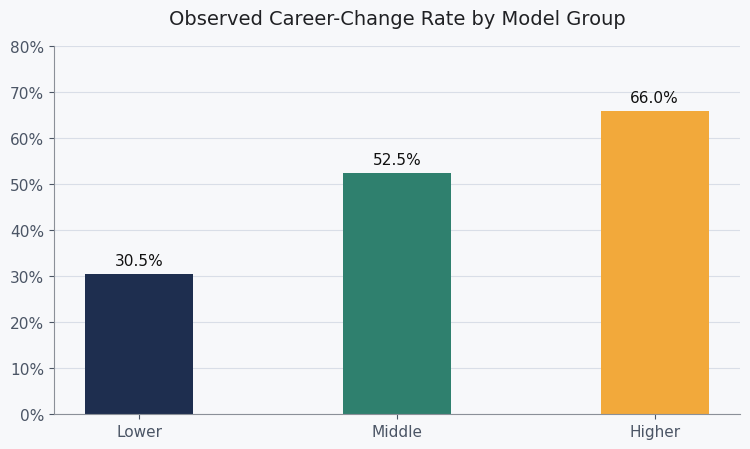

,Model Group,career_change_considered,Observed Rate
0,Lower,0.305085,30.508475
1,Middle,0.524923,52.492272
2,Higher,0.659898,65.989848


In [58]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

os.makedirs("img", exist_ok=True)

# Get model probability scores for the positive class
# Use whichever model variable you used for your final classifier
y_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Create results dataframe from actual test-set outcomes
band_df = pd.DataFrame({
    "predicted_probability": y_proba,
    "career_change_considered": y_test.values
})

# Create model score bands
band_df["Model Group"] = pd.cut(
    band_df["predicted_probability"],
    bins=[0, 0.40, 0.60, 1.00],
    labels=["Lower", "Middle", "Higher"],
    include_lowest=True
)

# Calculate observed career-change rate within each model group
band_summary = (
    band_df.groupby("Model Group", observed=True)["career_change_considered"]
    .mean()
    .reset_index()
)

band_summary["Observed Rate"] = band_summary["career_change_considered"] * 100

# Deck colors
colors = ["#1E2E4F", "#2F806E", "#F2A93B"]
grid_color = "#D9DEE7"
background = "#F7F8FA"

fig, ax = plt.subplots(figsize=(7.6, 4.6))

fig.patch.set_facecolor(background)
ax.set_facecolor(background)

bars = ax.bar(
    band_summary["Model Group"].astype(str),
    band_summary["Observed Rate"],
    color=colors,
    width=0.42
)

ax.set_title(
    "Observed Career-Change Rate by Model Group",
    fontsize=14,
    pad=16,
    color="#202124"
)

ax.set_ylim(0, 80)
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

ax.grid(axis="y", color=grid_color, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#8B9098")
ax.spines["bottom"].set_color("#8B9098")

ax.tick_params(axis="x", labelsize=11, colors="#4B5565")
ax.tick_params(axis="y", labelsize=11, colors="#4B5565")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.2,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#111111"
    )

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("img/model_band_chart.png", dpi=300, bbox_inches="tight")
plt.show()

# Optional: display the values so you can confirm them
band_summary

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

os.makedirs("img", exist_ok=True)

# ------------------------------------------------------------
# Pull feature names and importances from the trained model


# This assumes your fitted pipeline is named rf_classifier
# and has steps named "preprocessor" and "model"
preprocessor = rf_classifier.named_steps["preprocessor"]
model = rf_classifier.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
feature_importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# ------------------------------------------------------------
# Map individual model features into broader factor groups

def assign_factor_group(feature_name):
    feature_name = feature_name.lower()

    if (
        "yearscode" in feature_name
        or "workexp" in feature_name
        or "salary" in feature_name
        or "convertedcompyearly" in feature_name
    ):
        return "Experience & Compensation"

    elif (
        "aithreat" in feature_name
        or "aiselect" in feature_name
        or "learned_ai" in feature_name
    ):
        return "AI Use & Attitudes"

    elif (
        "learned_online_courses" in feature_name
        or "learned_school" in feature_name
        or "learned_bootcamp" in feature_name
        or "learned_docs" in feature_name
        or "learned_on_job" in feature_name
        or "learned_books" in feature_name
        or "learned_videos" in feature_name
    ):
        return "Learning Pathways"

    elif (
        "remotework" in feature_name
        or "orgsize" in feature_name
    ):
        return "Work Setting"

    elif "edlevel" in feature_name:
        return "Education"

    else:
        return "Other"

importance_df["Factor"] = importance_df["Feature"].apply(assign_factor_group)

# ------------------------------------------------------------
#  Sum importances by factor group


factor_df = (
    importance_df
    .groupby("Factor", as_index=False)["Importance"]
    .sum()
)

# Optional: remove "Other" if it appears and is tiny/unwanted
factor_df = factor_df[factor_df["Factor"] != "Other"].copy()

# Convert to percent of total displayed importance
factor_df["Relative Importance"] = (
    factor_df["Importance"] / factor_df["Importance"].sum() * 100
)

# Keep order from smallest to largest so largest appears at bottom
factor_df = factor_df.sort_values("Relative Importance", ascending=True)

factor_df

,Factor,Importance,Relative Importance
1,Education,0.087641,8.764055
3,Learning Pathways,0.151344,15.134373
4,Work Setting,0.162765,16.276535
0,AI Use & Attitudes,0.267464,26.746388
2,Experience & Compensation,0.330786,33.078649


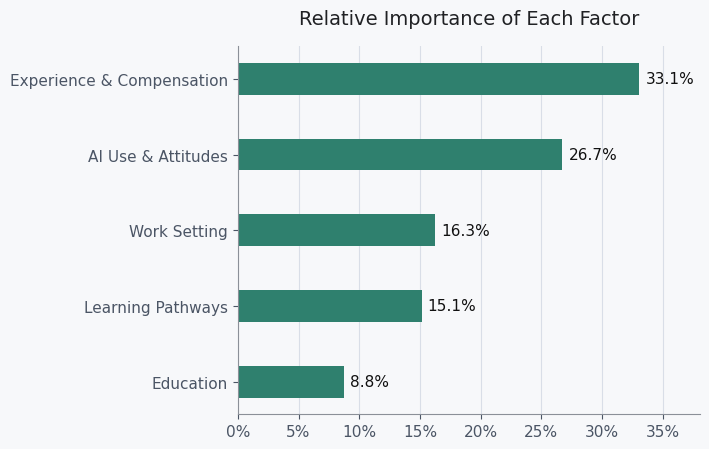

In [ ]:
bar_color = "#2F806E"
text_color = "#1E2E4F"
grid_color = "#D9DEE7"

fig, ax = plt.subplots(figsize=(7.2, 4.6))

fig.patch.set_facecolor("#F7F8FA")
ax.set_facecolor("#F7F8FA")

bars = ax.barh(
    factor_df["Factor"],
    factor_df["Relative Importance"],
    color=bar_color,
    height=0.42
)

ax.set_title(
    "Relative Importance of Each Factor",
    fontsize=14,
    pad=16,
    color="#202124"
)

ax.set_xlim(0, max(35, factor_df["Relative Importance"].max() + 5))
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

ax.grid(axis="x", color=grid_color, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#8B9098")
ax.spines["bottom"].set_color("#8B9098")

ax.tick_params(axis="x", labelsize=11, colors="#4B5565")
ax.tick_params(axis="y", labelsize=11, colors="#4B5565")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        ha="left",
        fontsize=11,
        color="#111111"
    )

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("img/career_change_factors_from_model.png", dpi=300, bbox_inches="tight")
plt.show()